# **Title: Customer Churn Prediction**

**Goal:** Identify customers likely to leave a service or subscription.

**Guidelines:**

* Use historical customer data (usage, support calls, activity logs)

* Preprocess imbalanced data using SMOTE or similar

* Apply Logistic Regression, Decision Trees, or Neural Networks

# **Project Introduction**

> Customer churn is a critical challenge for businesses, as losing existing customers can lead to significant revenue loss. This project focuses on analyzing customer data to identify the key factors influencing churn and building predictive models to detect customers who are likely to leave the service.
>
> The project follows a structured data analytics workflow, including data preprocessing, exploratory data analysis, feature selection, and model building using techniques such as Logistic Regression, Decision Tree, and Neural Networks. To address class imbalance, SMOTE was applied to improve model performance in identifying churn customers.
>
> By combining data-driven insights with machine learning models, the project aims to help businesses proactively reduce churn and improve customer retention strategies.

# **Dataset Description:**

The Telco Customer Churn dataset contains information about 7,043 customers, including demographic details, services subscribed, account information, and billing data. The dataset consists of 21 features and a target variable "Churn", which indicates whether a customer has left the service. The objective is to analyze customer behavior and build machine learning models to predict churn, helping businesses improve customer retention strategies.

**Total Records:** 7043 customers

**Total Features:** 21 columns

**The data set includes information about:**

* Customers who left within the last month – the column is called Churn
* Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
* Demographic info about customers – gender, age range, and if they have partners and dependents

| Column          | Meaning               |
| --------------- | --------------------- |
| `customerID` | Unique ID |
| `gender`        | Male / Female         |
| `SeniorCitizen` | 1 = Yes, 0 = No       |
| `Partner`       | Has partner or not    |
| `Dependents`    | Has dependents or not |
| `tenure`           | Number of months customer stayed     |
| `Contract`         | Month-to-month / One year / Two year |
| `PaperlessBilling` | Yes / No                             |
| `PaymentMethod`    | Payment type                         |
| `PhoneService`     | Has phone service      |
| `MultipleLines`    | Multiple lines or not  |
| `InternetService`  | DSL / Fiber optic / No |
| `OnlineSecurity`   | Yes / No               |
| `OnlineBackup`     | Yes / No               |
| `DeviceProtection` | Yes / No               |
| `TechSupport`      | Yes / No               |
| `StreamingTV`      | Yes / No               |
| `StreamingMovies`  | Yes / No               |
| `MonthlyCharges`   | Monthly bill amount    |
| `TotalCharges`     | Total amount paid      |
| `PaperlessBilling` | Digital billing or not |




### **Data Loading**

In [ ]:
import pandas as pd
df=pd.read_csv("/content/customer_churn_prediction.csv")
display(df.head(5))
display(df.info())
display(df.describe())
display(df.shape,df.columns)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


(7043, 21)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### **Data Preprocessing**

In [ ]:
print("Missing values:\n",df.isnull().sum())

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
df.drop(columns=["customerID"],inplace=True)
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

The customerID column was removed from the dataset as it serves only as a unique identifier and does not contribute any meaningful information for predicting customer churn. Including such features can introduce noise and negatively impact model performance.

### **Handling TotalCharges column**

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
display(df['TotalCharges'].dtype)
display(df['TotalCharges'].head())

/tmp/ipykernel_786/2945762918.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


dtype('float64')

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65


The `TotalCharges` column was converted from an object type to a numeric (float64) type. Any non-numeric values were coerced to `NaN` and then imputed with the median of the column to handle missing data gracefully. This ensures the column can be used in numerical calculations and model training.

### **Encoding the Target Variable**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
display(df['Churn'].value_counts())
display(df['Churn'].head())

,count
Churn,
0,5174
1,1869


,Churn
0,0
1,0
2,1
3,0
4,1


The `Churn` column, which is the target variable, was converted from a categorical string type (Yes/No) to a numerical type (1/0) using `LabelEncoder`. This is a necessary step for machine learning models that require numerical input for the target variable.

### **One-Hot Encoding for Categorical Features**

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns to one-hot encode: {list(categorical_cols)}")
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df_encoded.head())
display(df_encoded.shape)

Categorical columns to one-hot encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


(7043, 31)

All remaining categorical columns were converted into numerical format using one-hot encoding. The `drop_first=True` argument was used to avoid multicollinearity by dropping the first category for each feature. This process expands the dataset into more columns but allows machine learning models to correctly interpret the categorical data.

### **EDA**

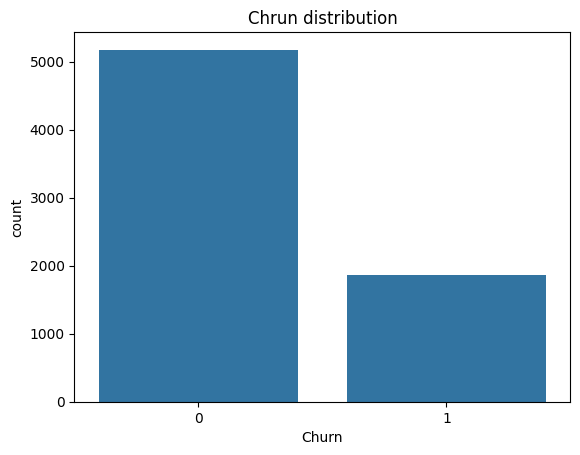

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Churn",data=df)
plt.title("Chrun distribution")
plt.show()

**Interpretation:**
Observing a significant imbalance in the dataset. The bar for '0' (customers who did not churn) is much taller than the bar for '1' (customers who churned). This means there are far more customers who stayed with the service than those who left.

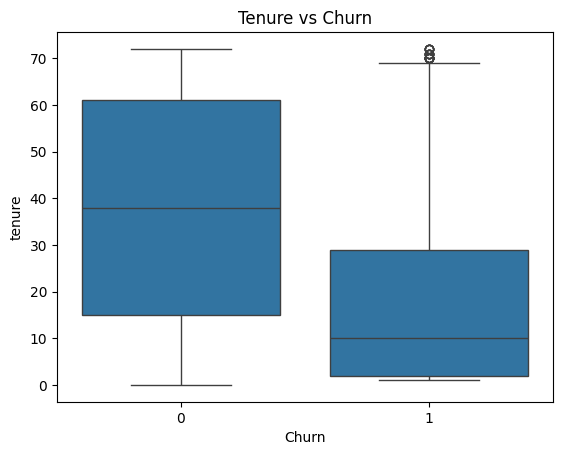

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

**Interpretation:**
The plot clearly shows that longer tenure is associated with a lower likelihood of churning. New or relatively new customers are at a higher risk of churning, while customers who have stayed for a long time are more likely to remain with the service.

Although most churn occurs among customers with low tenure, the presence of outliers indicates that even long-term customers can churn. This suggests that tenure alone is not sufficient to guarantee retention, and other factors such as pricing, service quality, or customer experience may also influence churn.

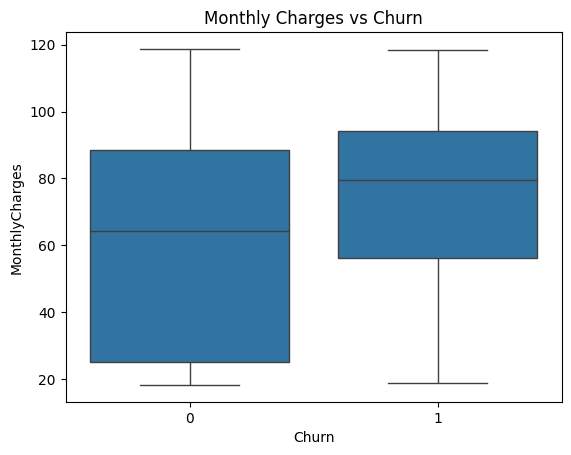

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

**Interpretation:** Customers with higher MonthlyCharges appear to have a higher propensity to churn. The box for churned customers (1) is generally higher on the MonthlyCharges axis than that for non-churned customers (0). This suggests that customers paying more per month might be more sensitive to the value they perceive from the service and are more likely to leave if they feel they are overpaying or can get a better deal elsewhere.

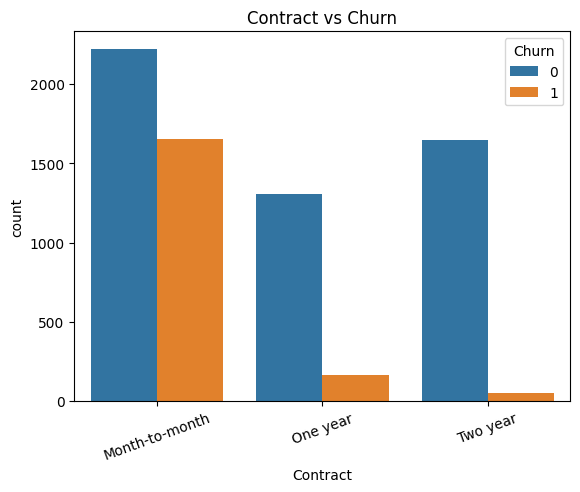

In [ ]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract vs Churn")
plt.xticks(rotation=20)
plt.show()

**Interpretation:** A strong relationship exists between contract type and churn. Customers on a 'Month-to-month' contract have a significantly higher churn rate compared to those on 'One year' or 'Two year' contracts. This is intuitive, as month-to-month contracts offer more flexibility and fewer obligations, making it easier for customers to switch providers. Long-term contracts (One year, Two year) imply a commitment, leading to lower churn.

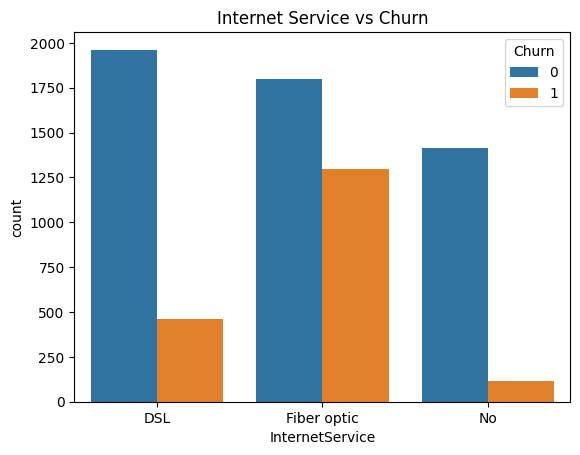

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

**Interpretation:** Customers with 'Fiber optic' internet service show a considerably higher churn rate compared to those with 'DSL' or no internet service. This might suggest issues related to the quality, reliability, or cost of the fiber optic service. Customers with 'DSL' or 'No' internet service generally have lower churn rates, with 'No' internet service having the lowest churn.

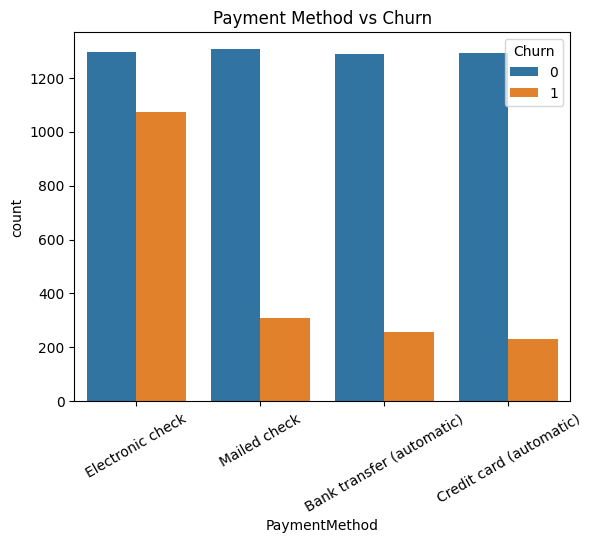

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.title("Payment Method vs Churn")
plt.show()

**Interpretation:** Customers using 'Electronic check' as their payment method exhibit a notably higher churn rate than those using other methods like 'Mailed check', 'Bank transfer (automatic)', or 'Credit card (automatic)'. This could be due to various factors, such as electronic checks being associated with less stable payment behavior or perhaps a less convenient user experience that leads to frustration and churn. Automated payment methods ('Bank transfer (automatic)', 'Credit card (automatic)') generally show lower churn rates, indicating a preference for convenience and stability among long-term customers.

### **Final analysis from plots:**
The exploratory data analysis reveals that customer churn is influenced by multiple factors. Customers are more likely to churn if they are relatively new, have higher monthly charges, are on flexible month-to-month contracts, use fiber optic internet, or rely on electronic check payment methods. In contrast, customers with longer tenure, lower monthly charges, long-term contracts, and automated payment methods demonstrate higher retention. These findings provide a comprehensive understanding of churn behavior and highlight key areas where businesses can implement targeted strategies to improve customer retention.

### **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression #WITHOUT APPLYING SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
model_lr = LogisticRegression()
model_lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
X_test_scaled = scaler.transform(X_test)
y_pred_lr = model_lr.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8197303051809794

Confusion Matrix:
 [[933 103]
 [151 222]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



**Interpretation:**
* Before applying SMOTE, the model shows a relatively high overall **accuracy of 82.0%**. However, when we look closer at the individual classes, we see a disparity.
* The model performs very well in predicting customers who do not **churn (Class 0)**, with **high precision (86%)** and **recall (90%)**. This is expected due to the dataset's imbalance, where the majority class (no churn) is easier to predict.
* For customers who do **churn (Class 1)**, the **recall** is only **60%**, meaning the model correctly identifies **only 60% of actual churners**.
* This suggests that a significant number of potential churners are being missed, which is a common problem in **imbalanced datasets** where the minority class is often overlooked by the model.

In [ ]:
from imblearn.over_sampling import SMOTE #APPLYING SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
model_lr_smote = LogisticRegression()
model_lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_lr_smote.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))

Accuracy: 0.7558552164655784

Confusion Matrix:
 [[754 282]
 [ 62 311]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



**Interpretation:**
* After applying SMOTE (Synthetic Minority Over-sampling Technique), the overall **accuracy slightly decreased to about 75.6%.**
* However, the key improvement is seen in the recall for the minority class (Churn). The **recall** for Class 1 (Churn) significantly increased from **0.60 to 0.83**.
* This means the model is now much better at identifying actual churners.
* This improvement comes at a trade-off: the precision for Class 1 decreased to **0.52** (meaning more false positives are predicted as churn), and the **recall** for Class 0 (No Churn) also **decreased to 0.73** (meaning some non-churners are now incorrectly predicted as churners).

## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier #WITHOUT APPLYING SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = model_dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.7097232079489

Confusion Matrix:
 [[831 205]
 [204 169]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80      1036
           1       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



**Interpretation:**
* Without SMOTE, the Decision Tree model achieves an **accuracy of about 71.0%.**
* It performs reasonably well for the majority class (Class 0, no churn), with a balanced precision and **recall of 80%**. However, for the minority class (Class 1, churn), both **precision and recall** are significantly **lower at 45%**.
* This means that the model is not very good at identifying actual churners, as it misses more than half of them (low recall) and a significant portion of its positive predictions for churn are incorrect (low precision).
* This is typical for **imbalanced datasets** where the model is biased towards the majority class.

In [ ]:
model_dt_smote = DecisionTreeClassifier(random_state=42) #APPLYING SMOTE
model_dt_smote.fit(X_train_smote, y_train_smote)
y_pred_dt_smote = model_dt_smote.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt_smote))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_smote))

Accuracy: 0.5947480482611781

Confusion Matrix:
 [[670 366]
 [205 168]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.65      0.70      1036
           1       0.31      0.45      0.37       373

    accuracy                           0.59      1409
   macro avg       0.54      0.55      0.54      1409
weighted avg       0.65      0.59      0.61      1409



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


**Interpretation:**
* After applying SMOTE, the overall accuracy of the Decision Tree model significantly **drops to about 59.5%**.
* Looking at the individual classes, the **recall for Class 1 (Churn)** remains at **45%**, showing no improvement, and the precision for **Class 1** drastically decreases to **0.31.**
* This indicates that while SMOTE was applied, it did not help the Decision Tree model in improving its ability to correctly identify churners (recall is unchanged), but it led to a significant increase in false positives (precision dropped).
* The performance on **Class 0** (No Churn) also deteriorated, with **recall dropping from 0.80 to 0.65.**

## **Neural Network**

In [ ]:
from sklearn.neural_network import MLPClassifier #Neural Network WITH NO SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
model_nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

model_nn.fit(X_train_scaled, y_train)
y_pred_nn = model_nn.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))

Accuracy: 0.765791341376863

Confusion Matrix:
 [[889 147]
 [183 190]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84      1036
           1       0.56      0.51      0.54       373

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



**Interpretation:**
* Without SMOTE, the Neural Network model
achieved an overall **accuracy of about 76.6%**. Similar to Logistic Regression, it showed good performance for the majority class (No Churn), **with high precision (83%) and recall (86%).**
* However, for the minority class (Churn), the **recall was lower at 51%**, meaning nearly half of the actual churners were missed. The **precision for churn (56%)** was also not very high, indicating a fair number of false positives.
* This performance suggests that the model is biased towards the majority class due to the imbalanced dataset.

In [ ]:
model_nn_smote = MLPClassifier( #Neural Network WITH SMOTE
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
model_nn_smote.fit(X_train_smote, y_train_smote)
y_pred_nn_smote = model_nn_smote.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_nn_smote))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn_smote))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn_smote))

Accuracy: 0.751596877217885

Confusion Matrix:
 [[830 206]
 [144 229]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.83      1036
           1       0.53      0.61      0.57       373

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



**Interpretation:**
* After applying SMOTE, the overall **accuracy** of the Neural Network model slightly decreased to **about 75.2%**.
* However, for the minority class (Churn), the **recall improved from 51% to 61%**. This means the model became better at identifying actual churners.
* This improvement in recall came with a slight decrease in **precision for Class 1 (from 56% to 53%)** and a slight decrease in **recall for Class 0 (from 86% to 80%)**. The **F1-score for Class 1** also saw a small improvement from **0.54 to 0.57**.



# **Final Comparison Table**

| Model                          | Accuracy | Recall (Churn) | Precision (Churn) | F1-Score (Churn) | Observation                             |
| ------------------------------ | -------- | -------------- | ----------------- | ---------------- | --------------------------------------- |
| Logistic Regression (No SMOTE) | 82.0%    | 0.60           | 0.70 (approx)     | ~0.65            | High accuracy but misses many churners  |
| Logistic Regression (SMOTE)    | 75.6%    | 0.83      | 0.52              | ~0.64            | Best at identifying churn (high recall) |
| Decision Tree (No SMOTE)       | 71.0%    | 0.45           | 0.45              | ~0.45            | Poor performance on churn class         |
| Decision Tree (SMOTE)          | 59.5%    | 0.45           | 0.31              | ~0.37            | Performance worsened                    |
| Neural Network (No SMOTE)      | 76.6%    | 0.51           | 0.56              | 0.54             | Moderate performance                    |
| Neural Network (SMOTE)         | 75.2%    | 0.61           | 0.53              | 0.57             | Improved but not best                   |


# **Final Conclusion**

> This project aimed to predict customer churn using multiple machine learning models, including Logistic Regression, Decision Tree, and Neural Network. The dataset exhibited class imbalance, which significantly impacted model performance, particularly in identifying churn customers.

> To address this issue, SMOTE was applied to improve the representation of the minority class. The results showed that the impact of SMOTE varied across models. Logistic Regression demonstrated a significant improvement in recall for churn customers, increasing from 60% to 83%, making it the most effective model for identifying potential churners. The Neural Network showed moderate improvement, while the Decision Tree model did not benefit from SMOTE and experienced a decline in performance.

> Based on the evaluation metrics, particularly recall and F1-score for the churn class, Logistic Regression with SMOTE was selected as the best-performing model. Although it had slightly lower overall accuracy, it was more effective in detecting customers at risk of churn, which is critical for business decision-making.




#  **Business Suggestions**

* Focus on improving the onboarding experience for new customers to reduce early-stage churn.

* Provide welcome offers, guidance, and support during the initial months of service.

* Introduce flexible pricing strategies to reduce churn among high-paying customers.

* Offer discounts, loyalty rewards, or bundled service packages to increase perceived value.

* Encourage customers to opt for long-term contracts by providing incentives such as discounts or added benefits.

* Reduce dependency on month-to-month contracts to improve customer retention.

* Improve the quality and reliability of fiber optic services to address higher churn rates among these users.

* Actively monitor customer feedback and resolve service-related issues quickly.

* Promote automated payment methods such as credit cards or bank transfers.

* Provide small incentives or cashback offers for customers who switch to auto-pay options.

* Use predictive models to identify high-risk customers and take proactive retention measures.

* Implement targeted marketing campaigns and personalized offers for customers likely to churn.

